#Principal Component Analysis (Dimentionality Reduction)
**Principal Component Analysis** is a dimensionality reduction technique used in data science and machine learning. It transforms a high-dimensional dataset into a lower-dimensional one by:

1. Identifying the principal components (directions of maximum variance)

2. Projecting the data onto these components

3. Preserving as much information (variance) as possible

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

##Load dataset

In [3]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# 1st Way

In [4]:
s_dum = pd.get_dummies(df.Sex)
s_dum

,F,M
0,False,True
1,True,False
2,False,True
3,True,False
4,False,True
...,...,...
913,False,True
914,False,True
915,False,True
916,True,False


In [5]:
dum_cp = pd.get_dummies(df.ChestPainType)
dum_cp

,ASY,ATA,NAP,TA
0,False,True,False,False
1,False,False,True,False
2,False,True,False,False
3,True,False,False,False
4,False,False,True,False
...,...,...,...,...
913,False,False,False,True
914,True,False,False,False
915,True,False,False,False
916,False,True,False,False


In [6]:
rest_dum = pd.get_dummies(df.RestingECG)
rest_dum

,LVH,Normal,ST
0,False,True,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False
...,...,...,...
913,False,True,False
914,False,True,False
915,False,True,False
916,True,False,False


In [7]:
ex_dum = pd.get_dummies(df.ExerciseAngina)
ex_dum

,N,Y
0,True,False
1,True,False
2,True,False
3,False,True
4,True,False
...,...,...
913,True,False
914,True,False
915,False,True
916,True,False


In [8]:
st_dum = pd.get_dummies(df.ST_Slope)
st_dum

,Down,Flat,Up
0,False,False,True
1,False,True,False
2,False,False,True
3,False,True,False
4,False,False,True
...,...,...,...
913,False,True,False
914,False,True,False
915,False,True,False
916,False,True,False


In [9]:
X = pd.concat([df['Age'],s_dum, dum_cp, df.loc[:,['RestingBP','Cholesterol','FastingBS']], rest_dum, df['MaxHR'], ex_dum, df['Oldpeak'], st_dum],axis=1)
X

,Age,F,M,ASY,ATA,NAP,TA,RestingBP,Cholesterol,FastingBS,LVH,Normal,ST,MaxHR,N,Y,Oldpeak,Down,Flat,Up
0,40,False,True,False,True,False,False,140,289,0,False,True,False,172,True,False,0.0,False,False,True
1,49,True,False,False,False,True,False,160,180,0,False,True,False,156,True,False,1.0,False,True,False
2,37,False,True,False,True,False,False,130,283,0,False,False,True,98,True,False,0.0,False,False,True
3,48,True,False,True,False,False,False,138,214,0,False,True,False,108,False,True,1.5,False,True,False
4,54,False,True,False,False,True,False,150,195,0,False,True,False,122,True,False,0.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,False,True,False,False,False,True,110,264,0,False,True,False,132,True,False,1.2,False,True,False
914,68,False,True,True,False,False,False,144,193,1,False,True,False,141,True,False,3.4,False,True,False
915,57,False,True,True,False,False,False,130,131,0,False,True,False,115,False,True,1.2,False,True,False
916,57,True,False,False,True,False,False,130,236,0,True,False,False,174,True,False,0.0,False,True,False


In [10]:
y = df.HeartDisease
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

# Alternative Way

In [11]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
mean_bp = df.RestingBP.mean()
df['RestingBP'] = df['RestingBP'].replace(0, mean_bp)
df['Cholesterol'] = df['Cholesterol'].replace(0, df.Cholesterol.mean())
df['FastingBS'] = df['FastingBS'].replace(0, df.FastingBS.mean())
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0.233115,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0.233115,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0.233115,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0.233115,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0.233115,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0.233115,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1.000000,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0.233115,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0.233115,LVH,174,N,0.0,Flat,1


In [13]:
df[df.RestingBP==0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [14]:
df = pd.get_dummies(df)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0.233115,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0.233115,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0.233115,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0.233115,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0.233115,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0.233115,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144.0,193.0,1.000000,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130.0,131.0,0.233115,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130.0,236.0,0.233115,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [15]:
X = df.drop('HeartDisease',axis='columns')
y = df.HeartDisease
print(X)
print(y)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  \
0     40      140.0        289.0   0.233115    172      0.0  False   True   
1     49      160.0        180.0   0.233115    156      1.0   True  False   
2     37      130.0        283.0   0.233115     98      0.0  False   True   
3     48      138.0        214.0   0.233115    108      1.5   True  False   
4     54      150.0        195.0   0.233115    122      0.0  False   True   
..   ...        ...          ...        ...    ...      ...    ...    ...   
913   45      110.0        264.0   0.233115    132      1.2  False   True   
914   68      144.0        193.0   1.000000    141      3.4  False   True   
915   57      130.0        131.0   0.233115    115      1.2  False   True   
916   57      130.0        236.0   0.233115    174      0.0   True  False   
917   38      138.0        175.0   0.233115    173      0.0  False   True   

     ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  \
0          

# Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Before PCA

In [17]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),X_train, y_train)

print(rf)

[0.80952381 0.89115646 0.86394558 0.83673469 0.84931507]


In [18]:
lr = cross_val_score(LogisticRegression(max_iter=5000),X_train, y_train)

print(lr)

[0.80952381 0.8707483  0.87755102 0.81632653 0.84246575]


In [19]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6902173913043478

# After PCA

## Normalize the Feature Matrix (X) with Standard Scaling


In [20]:
scalar = StandardScaler()
scaled_x = scalar.fit_transform(X)
scaled_x.shape

(918, 20)

## Perform Dimensionality Reduction Using PCA (95% Variance Retained)


In [21]:
pca = PCA(0.95)
x_pca = pca.fit_transform(scaled_x)
x_pca.shape

(918, 13)

#Train test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2)

##Train on KNN

In [23]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8695652173913043

##Random Forest

In [24]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),X_train, y_train)

print(rf)

[0.80952381 0.82993197 0.80272109 0.89115646 0.83561644]


##Logistic Regression

In [25]:
lr = cross_val_score(LogisticRegression(max_iter=150),X_train, y_train)

print(lr)

[0.80952381 0.86394558 0.81632653 0.93197279 0.85616438]


##Try retaining less variance using PCA and determine how it makes a difference.

In [26]:
# Try several variance retention levels
variance_levels = [0.95, 0.90, 0.80, 0.70, 0.50]
results = []

for var in variance_levels:
    # Apply PCA at this variance level
    pca = PCA(var)
    x_pca_var = pca.fit_transform(scaled_x)
    n_components = x_pca_var.shape[1]

    # Train/test split (same split logic as before)
    X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
        x_pca_var, y, test_size=0.2, random_state=42
    )

    # Random Forest
    rf_scores = cross_val_score(RandomForestClassifier(n_estimators=35, random_state=42),
                                 X_train_v, y_train_v)

    # Logistic Regression
    lr_scores = cross_val_score(LogisticRegression(max_iter=5000),
                                 X_train_v, y_train_v)

    # KNN
    knn = KNeighborsClassifier(n_neighbors=9)
    knn.fit(X_train_v, y_train_v)
    knn_score = knn.score(X_test_v, y_test_v)

    results.append({
        'Variance Retained': var,
        'Num Components': n_components,
        'RF Mean CV Score': rf_scores.mean(),
        'LR Mean CV Score': lr_scores.mean(),
        'KNN Test Score': knn_score
    })

# Display as a comparison table
results_df = pd.DataFrame(results)
print(results_df)

   Variance Retained  Num Components  RF Mean CV Score  LR Mean CV Score  \
0               0.95              13          0.852847          0.852819   
1               0.90              12          0.856938          0.856929   
2               0.80              10          0.850107          0.862399   
3               0.70               8          0.844637          0.865101   
4               0.50               5          0.843267          0.860992   

   KNN Test Score  
0        0.842391  
1        0.842391  
2        0.842391  
3        0.820652  
4        0.815217  


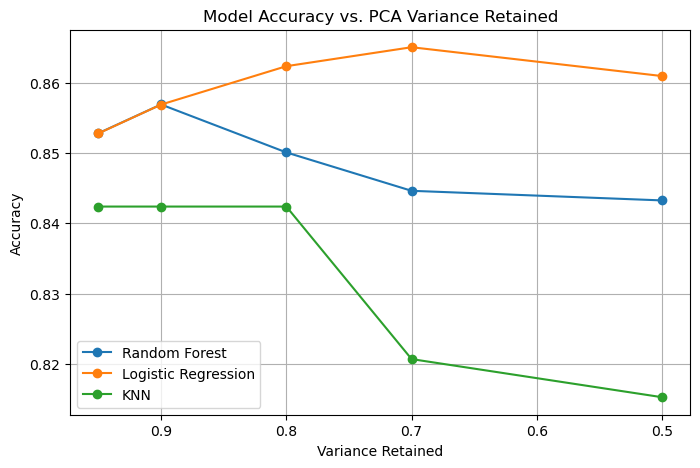

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df['Variance Retained'], results_df['RF Mean CV Score'], marker='o', label='Random Forest')
plt.plot(results_df['Variance Retained'], results_df['LR Mean CV Score'], marker='o', label='Logistic Regression')
plt.plot(results_df['Variance Retained'], results_df['KNN Test Score'], marker='o', label='KNN')

plt.gca().invert_xaxis()
plt.xlabel('Variance Retained')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs. PCA Variance Retained')
plt.legend()
plt.grid(True)
plt.show()